# Investment Funds Analysis

## Objective

Analyze a dataset of investment funds to explore the distribution of asset classes and identify European equity funds combining strong annual performance with relatively low management fees.

## 1. Data Loading and Exploration

Load the dataset and inspect its structure and main variables.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
investment_funds = pd.read_csv("investment_funds.csv")

In [5]:
funds = pd.DataFrame(investment_funds)

In [6]:
print(funds['fund_name'].count())

520


## 2. Asset Class Distribution

Analyze the number of funds across the different asset classes.

In [8]:
nb_funds = funds['asset_class'].value_counts()
print(nb_funds)

asset_class
Equity          217
Bond            150
Multi-Asset      81
Money Market     41
Alternative      31
Name: count, dtype: int64


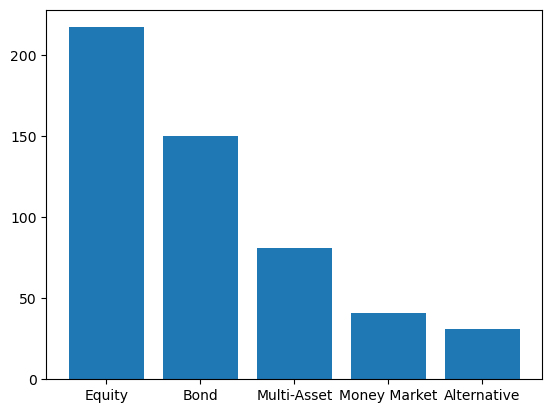

In [9]:
x = nb_funds.index
y = nb_funds.values

plt.bar(x,y)
plt.show()

## 3. European Equity Funds

Focus on European equity funds and identify those combining annual returns above 8% with management fees below 1%.

In [11]:
european_equity_funds = funds[(funds['asset_class']=='Equity') & (funds['region']=='Europe')]

In [12]:
print(european_equity_funds.head(5))

                             fund_name asset_class  region  launch_year  \
4   Beacon Europe Equity Opportunities      Equity  Europe         1999   
15        Northstar Europe Equity Core      Equity  Europe         2019   
17  Vertex Europe Equity Opportunities      Equity  Europe         2021   
27         Atlas Europe Equity Dynamic      Equity  Europe         1999   
32           Orion Europe Equity Focus      Equity  Europe         2023   

    aum_million_eur  annual_return_pct  volatility_pct  management_fee_pct  
4            4101.6               3.82           19.19                1.34  
15            818.6              16.10           15.57                1.03  
17            700.9               6.91           14.72                0.90  
27           1725.0              12.12           18.77                1.15  
32            285.7               9.29           16.49                0.85  


In [13]:
performance_above_height = european_equity_funds[european_equity_funds['annual_return_pct']>8.00]
print(performance_above_height.head(5))

                        fund_name asset_class  region  launch_year  \
15   Northstar Europe Equity Core      Equity  Europe         2019   
27    Atlas Europe Equity Dynamic      Equity  Europe         1999   
32      Orion Europe Equity Focus      Equity  Europe         2023   
74   Harbor Europe Equity Dynamic      Equity  Europe         2016   
107   Meridian Europe Equity Core      Equity  Europe         2002   

     aum_million_eur  annual_return_pct  volatility_pct  management_fee_pct  
15             818.6              16.10           15.57                1.03  
27            1725.0              12.12           18.77                1.15  
32             285.7               9.29           16.49                0.85  
74            1729.9              10.34           15.51                1.05  
107            476.0              12.80           17.56                0.84  


In [14]:
performance_and_low_fees = performance_above_height[performance_above_height['management_fee_pct']<1.00]
print(performance_and_low_fees.head(5))

                               fund_name asset_class  region  launch_year  \
32             Orion Europe Equity Focus      Equity  Europe         2023   
107          Meridian Europe Equity Core      Equity  Europe         2002   
114           Atlas Europe Equity Select      Equity  Europe         2015   
126         Meridian Europe Equity Focus      Equity  Europe         1999   
133  Compass Europe Equity Opportunities      Equity  Europe         1998   

     aum_million_eur  annual_return_pct  volatility_pct  management_fee_pct  
32             285.7               9.29           16.49                0.85  
107            476.0              12.80           17.56                0.84  
114            111.1              10.78           11.53                0.80  
126           1343.5               9.68           14.65                0.95  
133            234.8              17.31            7.22                0.76  


In [15]:
attractive_funds = performance_and_low_fees['fund_name'].count()
print(attractive_funds)

17


## Conclusion

What this dataset of 520 investment funds reveals:

- Equity is the most represented asset class, with 217 funds, followed by bonds (150) and multi-asset funds (81).
- 17 European equity funds have an annual return above 8% and management fees below 1%.